# XGBoost on Consolidated Categories

This notebook runs XGBoost against the **15-class consolidated target** (`parent_category`) produced by notebook 15.  
The professor's core insight: 1,625 classes with severe imbalance is the primary reason absolute accuracy looks low — reducing to 15 semantically coherent groups is the single biggest lever.

**Two experiments:**
1. **Primary** — XGBoost predicting `parent_category` (15 classes, same 153 features as notebook 11)
2. **Price-tier analysis** — breakdown of model performance by price tier (low/med/high) to show where predictions are strongest, as the professor requested

**Baseline for comparison (notebook 11):** 7.78% accuracy on 1,601 classes

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

print(f'XGBoost {xgb.__version__} imported OK')

XGBoost 3.2.0 imported OK


In [17]:
# ── GPU CONFIG ─────────────────────────────────────────────
USE_GPU = True
xgb_device = 'cuda' if USE_GPU else 'cpu'
xgb_njobs  = 1 if USE_GPU else -1
print(f'Device: {xgb_device}')
# ───────────────────────────────────────────────────────────

print('Loading cleaned_data_with_parent.csv ...')
data = pd.read_csv('../data/cleaned_data_with_parent.csv')
print(f'Done. Shape: {data.shape}')
print(f'Original categories : {data["Category"].nunique()}')
print(f'Consolidated groups  : {data["parent_category"].nunique()}')
print(f'Price tiers          : {sorted(data["price_tier"].unique())}')

Device: cuda
Loading cleaned_data_with_parent.csv ...
Done. Shape: (157026, 158)
Original categories : 1625
Consolidated groups  : 15
Price tiers          : [np.int64(0), np.int64(1), np.int64(2)]


## 1. Data Preparation

In [18]:
# Temporal split — same rule as all other notebooks
train = data[data['order_year'] <= 2021].copy()
test  = data[data['order_year'] > 2021].copy()

unseen = set(test['parent_category'].unique()) - set(train['parent_category'].unique())
if unseen:
    test = test[~test['parent_category'].isin(unseen)]
    print(f'Removed {len(unseen)} unseen parent categories from test')

drop_cols = ['Title', 'ASIN/ISBN (Product Code)', 'Category', 'parent_category']
X_train = train.drop(drop_cols, axis=1)
X_test  = test.drop(drop_cols, axis=1)

le = LabelEncoder()
le.fit(train['parent_category'])
y_train = le.transform(train['parent_category'])
y_test  = le.transform(test['parent_category'])
num_classes = len(le.classes_)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Build string class names from the mapping file (parent_category is stored as int IDs)
cat_map = pd.read_csv('../data/category_mapping.csv').drop_duplicates('parent_id')
id_to_label = cat_map.set_index('parent_id')['parent_label'].to_dict()
class_names = [id_to_label[int(c)] for c in le.classes_]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Classes ({num_classes}): {class_names}')

Train: (113655, 154) | Test: (43371, 154)
Classes (15): ['Kitchen_Home', 'Electronics_Accessories', 'Industrial_Auto', 'Home_Textiles', 'Consumer_Electronics', 'Toys_Games', 'Health_Beauty', 'Food_Nutrition', 'Books_Media', 'Home_Electrical', 'Office_Stationery', 'Sports_Fitness', 'Apparel', 'Tools_Hardware', 'Home_Decor']


## 2. XGBoost — 15-Class Consolidated Target

Using the best hyperparameters found in notebook 11 (tuned on the original 1,625-class problem) — no re-tuning needed for a proof-of-concept run.

In [19]:
%%time

# Best params from notebook 11 RandomizedSearchCV
best_params = {
    'n_estimators':     30,
    'max_depth':         5,
    'learning_rate':   0.2,
    'subsample':       1.0,
    'colsample_bytree': 1.0,
    'min_child_weight':  1,
}

xgb_model = xgb.XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=num_classes,
    tree_method='hist',
    device=xgb_device,
    n_jobs=xgb_njobs,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_scaled, y_train)
print('Model trained.')

Model trained.
CPU times: total: 11.8 s
Wall time: 2.59 s


In [20]:
y_pred = xgb_model.predict(X_test_scaled)

acc          = accuracy_score(y_test, y_pred)
f1_macro     = f1_score(y_test, y_pred, average='macro',    zero_division=0)
f1_weighted  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
prec_macro   = precision_score(y_test, y_pred, average='macro',    zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)

print('=== XGBoost — 15-Class Consolidated Target ===')
print(f'Accuracy:           {acc:.4f}  ({acc*100:.1f}%)')
print(f'Precision (macro):  {prec_macro:.4f}')
print(f'Recall (macro):     {recall_macro:.4f}')
print(f'F1 (macro):         {f1_macro:.4f}')
print(f'F1 (weighted):      {f1_weighted:.4f}')
print()
print('--- vs notebook 11 baseline (1,625 classes) ---')
print(f'  Original accuracy: 7.78%  →  Consolidated: {acc*100:.1f}%')
print()
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

=== XGBoost — 15-Class Consolidated Target ===
Accuracy:           0.2950  (29.5%)
Precision (macro):  0.2495
Recall (macro):     0.1578
F1 (macro):         0.1465
F1 (weighted):      0.2365

--- vs notebook 11 baseline (1,625 classes) ---
  Original accuracy: 7.78%  →  Consolidated: 29.5%

                         precision    recall  f1-score   support

           Kitchen_Home       0.25      0.01      0.02      2042
Electronics_Accessories       0.26      0.15      0.19      2986
        Industrial_Auto       0.26      0.07      0.11       979
          Home_Textiles       0.18      0.11      0.14      2583
   Consumer_Electronics       0.17      0.07      0.09       963
             Toys_Games       0.33      0.05      0.08      2060
          Health_Beauty       0.27      0.62      0.38      7318
         Food_Nutrition       0.40      0.55      0.47      7522
            Books_Media       0.43      0.14      0.21      2306
        Home_Electrical       0.24      0.01      0.01   

## 3. Confusion Matrix

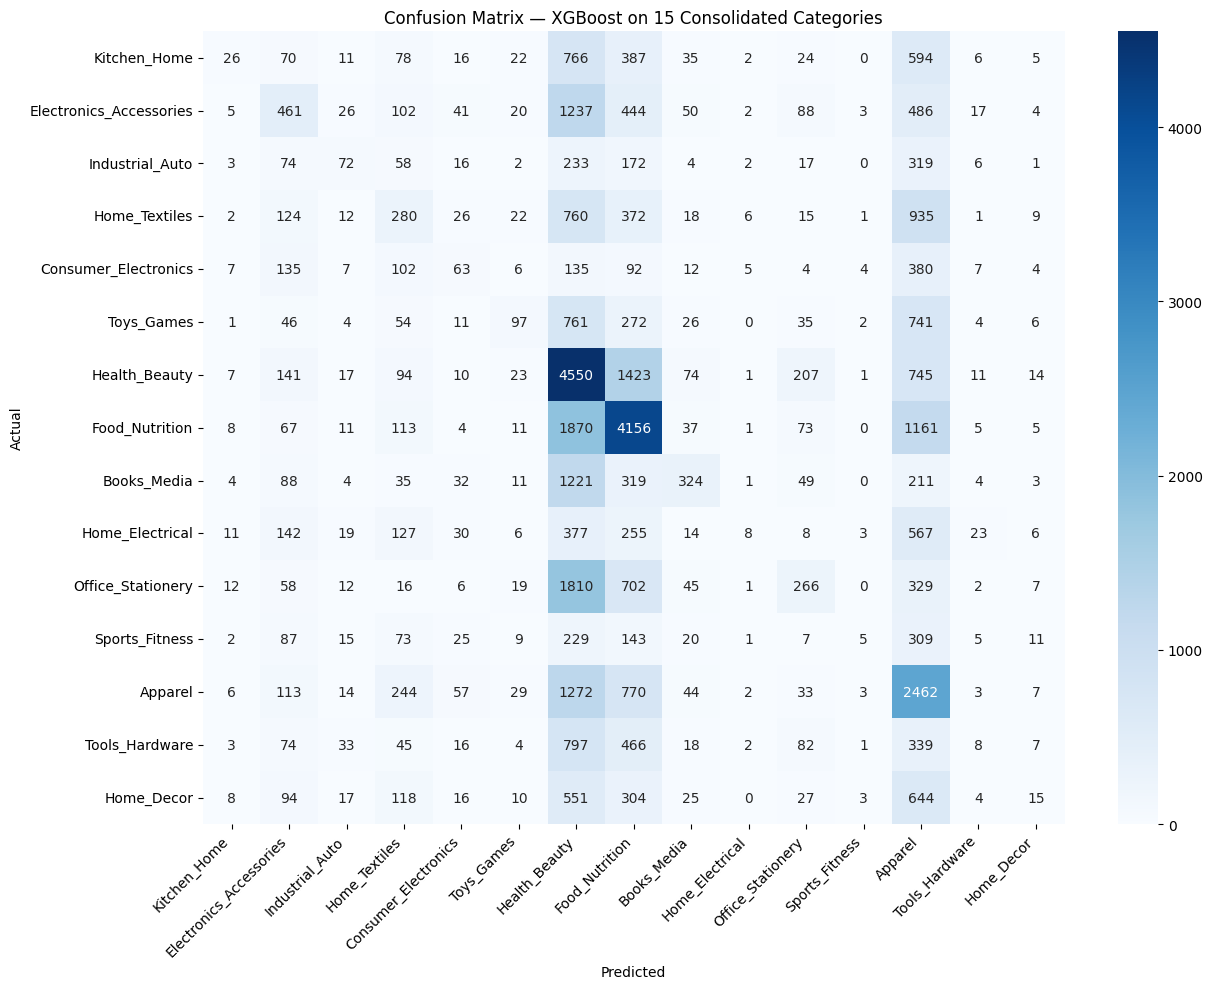

In [21]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — XGBoost on 15 Consolidated Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
cm_main = confusion_matrix(y_test, y_pred)
total = cm_main.sum()
rows = []
for i, name in enumerate(class_names):
    tp = int(cm_main[i, i])
    fp = int(cm_main[:, i].sum() - tp)
    fn = int(cm_main[i, :].sum() - tp)
    tn = int(total - tp - fp - fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    rows.append({"Class": name, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                 "Precision": round(prec,4), "Recall": round(rec,4), "F1": round(f1,4)})

metrics_df_15 = pd.DataFrame(rows).set_index("Class")
print("Per-class TP / TN / FP / FN - XGBoost 15-class (unweighted model):")
print(metrics_df_15.to_string())
print()
print(f"Overall Accuracy: {(y_test == y_pred).mean():.4f}")

from sklearn.metrics import f1_score
print()
print(f"F1 Macro    (unweighted avg over classes): {f1_score(y_test, y_pred, average='macro',    zero_division=0):.4f}")
print(f"F1 Weighted (weighted by class support):   {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 Micro    (global TP / FP / FN totals):  {f1_score(y_test, y_pred, average='micro',    zero_division=0):.4f}")


Per-class TP / TN / FP / FN - XGBoost 15-class (unweighted model):
                           TP     TN     FP    FN  Precision  Recall      F1
Class                                                                       
Kitchen_Home               26  41250     79  2016     0.2476  0.0127  0.0242
Electronics_Accessories   461  39072   1313  2525     0.2599  0.1544  0.1937
Industrial_Auto            72  42190    202   907     0.2628  0.0735  0.1149
Home_Textiles             280  39529   1259  2303     0.1819  0.1084  0.1359
Consumer_Electronics       63  42102    306   900     0.1707  0.0654  0.0946
Toys_Games                 97  41117    194  1963     0.3333  0.0471  0.0825
Health_Beauty            4550  24034  12019  2768     0.2746  0.6218  0.3810
Food_Nutrition           4156  29728   6121  3366     0.4044  0.5525  0.4670
Books_Media               324  40643    422  1982     0.4343  0.1405  0.2123
Home_Electrical             8  41749     26  1588     0.2353  0.0050  0.0098
Office_St

## 4. Feature Importance

Top 20 features for consolidated category prediction:
                                                          Feature  Importance
                life-changes_Lost a job ,Moved place of residence    0.033560
                                                   state_Nebraska    0.027993
                                                       price_tier    0.020670
                                          Purchase Price Per Unit    0.019985
                                                   state_New York    0.017130
                                        Shipping Address State_NE    0.015233
                                        Shipping Address State_TX    0.014539
                                        Shipping Address State_NV    0.014322
                                                    state_Alabama    0.014287
                                        sexual-orientation_LGBTQ+    0.013547
                       sexual-orientation_heterosexual (straight)    0.013436
          

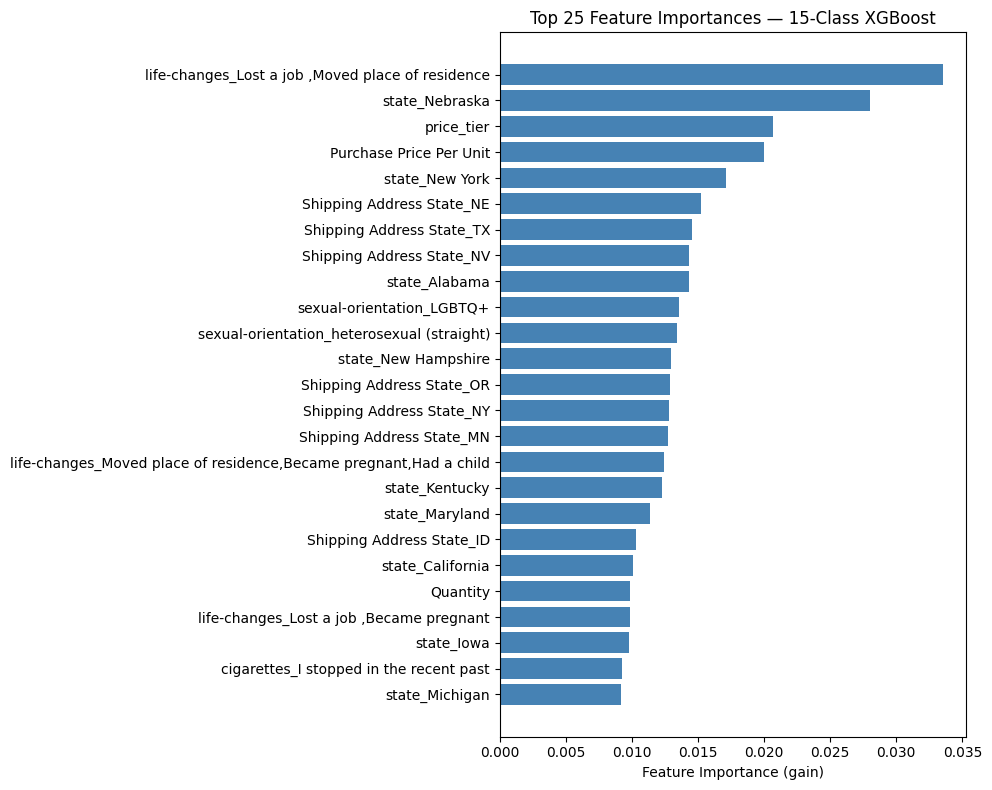

In [23]:
feat_imp = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 20 features for consolidated category prediction:')
print(feat_imp.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top = feat_imp.head(25)
ax.barh(range(25), top['Importance'].values, color='steelblue')
ax.set_yticks(range(25))
ax.set_yticklabels(top['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 25 Feature Importances — 15-Class XGBoost')
plt.tight_layout()
plt.show()

## 5. Price-Tier Performance Breakdown

The professor asked: how does performance vary by price tier (low/med/high within category)?  
This answers: *"are we better at predicting expensive purchases?"* — a key part of the Amazon relevance story.

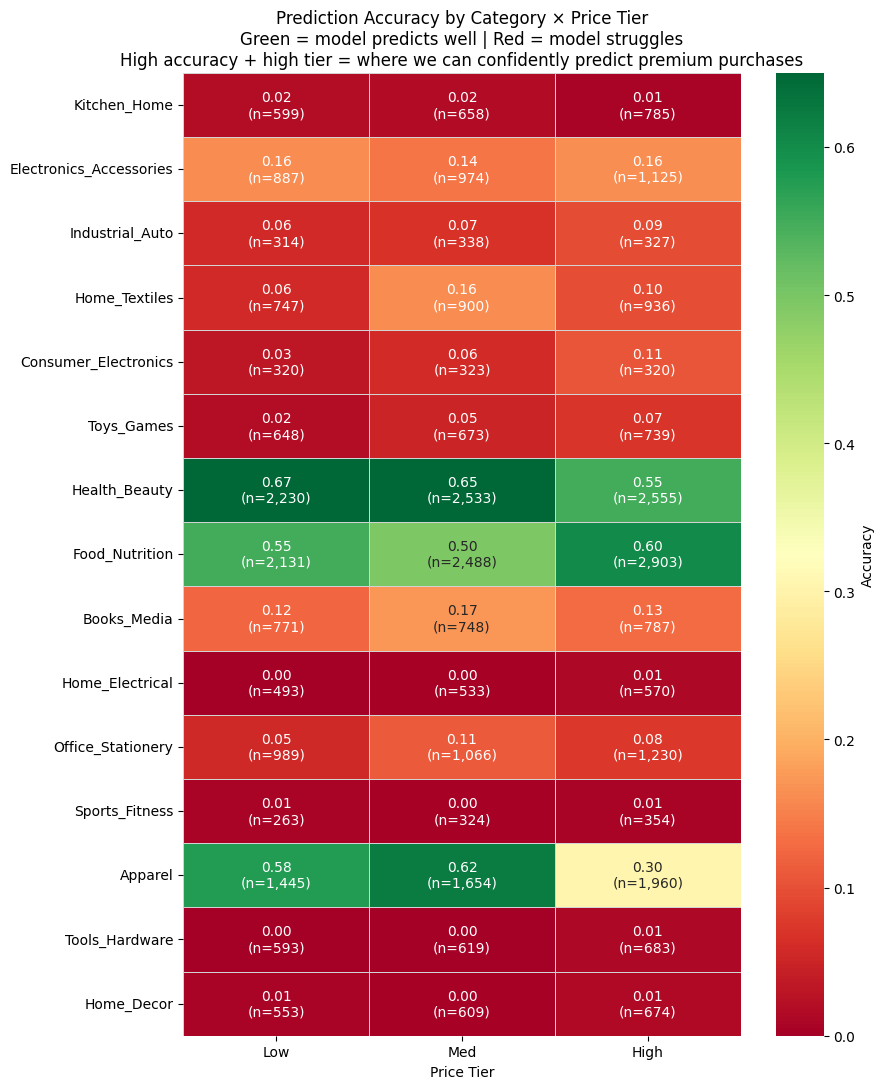

Overall accuracy by tier (all classes combined):
  Low: 0.300  (n=12,983)
  Med: 0.314  (n=14,440)
  High: 0.274  (n=15,948)

Best predicted category × tier combinations:
      Category Tier  Accuracy
 Health_Beauty  Low  0.673991
 Health_Beauty  Med  0.648638
       Apparel  Med  0.624547
Food_Nutrition High  0.603169
       Apparel  Low  0.577855
 Health_Beauty High  0.549511
Food_Nutrition  Low  0.548569
Food_Nutrition  Med  0.496785


In [24]:
results_df = pd.DataFrame({
    'true':       y_test,
    'pred':       y_pred,
    'price_tier': test['price_tier'].values,
    'correct':    (y_test == y_pred).astype(int)
})

# Per-class × price-tier accuracy heatmap
class_tier_acc = (
    results_df.groupby(['true', 'price_tier'])['correct']
    .mean().unstack(level=1)
)
class_tier_count = (
    results_df.groupby(['true', 'price_tier'])['correct']
    .count().unstack(level=1)
)

class_tier_acc.index   = [class_names[i] for i in class_tier_acc.index]
class_tier_count.index = [class_names[i] for i in class_tier_count.index]
class_tier_acc.columns   = ['Low', 'Med', 'High']
class_tier_count.columns = ['Low', 'Med', 'High']

# Build annotation strings without applymap (removed in pandas 2.2)
annot = class_tier_acc.map(lambda x: f'{x:.2f}') + '\n(' + \
        class_tier_count.map(lambda x: f'n={x:,}') + ')'

fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(
    class_tier_acc, annot=annot, fmt='', cmap='RdYlGn',
    vmin=0, vmax=0.65, ax=ax, linewidths=0.5, linecolor='lightgray',
    cbar_kws={'label': 'Accuracy'}
)
ax.set_title('Prediction Accuracy by Category × Price Tier\n'
             'Green = model predicts well | Red = model struggles\n'
             'High accuracy + high tier = where we can confidently predict premium purchases')
ax.set_xlabel('Price Tier')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Overall accuracy by tier (all classes combined):')
for tier, name in [(0, 'Low'), (1, 'Med'), (2, 'High')]:
    m = results_df['price_tier'] == tier
    print(f'  {name}: {results_df.loc[m, "correct"].mean():.3f}  (n={m.sum():,})')

acc_flat = class_tier_acc.stack().reset_index()
acc_flat.columns = ['Category', 'Tier', 'Accuracy']
print()
print('Best predicted category × tier combinations:')
print(acc_flat.sort_values('Accuracy', ascending=False).head(8).to_string(index=False))

## 6. Summary

All experiments use the full 157,026-row dataset. Temporal split: train = orders <= 2021 (113,655 rows), test = orders > 2021 (43,371 rows).

### Model Results

| Experiment | Classes | Accuracy | F1 (macro) | F1 (weighted) |
|------------|---------|----------|------------|---------------|
| XGBoost original (nb 11, 1,625 classes) | 1,625 | 7.78% | n/a | n/a |
| 15-class consolidated, unweighted | 15 | 29.5% | 0.1465 | 0.2365 |
| 15-class consolidated, class-balanced | 15 | 23.1% | 0.1841 | 0.2432 |
| Combined target (category x price tier) | 45 | 9.9% | 0.0439 | 0.0730 |

The class-balanced model trades 6.4pp accuracy for +3.8pp macro F1, spreading predictions across all 15 groups rather than concentrating on Food_Nutrition, Health_Beauty, and Apparel.

The combined target (45 classes) answers the professor's "category x price tier" question directly. 9.9% on a 45-class joint prediction is clean: price_tier and Purchase Price Per Unit are dropped from features to prevent leakage, so the model is genuinely predicting a harder joint problem.

### Market Opportunity (Section 8)

Top saturation groups by purchases per unique category listed:

| Group | Saturation | Volume | Avg Price |
|-------|-----------|--------|-----------|
| Food_Nutrition | 260.7 | 27,635 | $13.66 |
| Apparel | 184.1 | 17,301 | $23.23 |
| Health_Beauty | 160.9 | 24,779 | $15.09 |
| Electronics_Accessories | 124.5 | 12,077 | $40.21 |
| Consumer_Electronics | 48.0 | 4,028 | $46.49 |

Consumer_Electronics has the highest avg price ($46.49) despite low saturation, indicating a premium but underserved segment relative to demand.

### Cross-Category Investment Map (Section 8b)

Co-purchase heatmap: for each (A, B) pair, shows the avg highest price paid in B by customers who also bought in A. Cells with fewer than 20 cross-buying customers are masked. Answers: if a seller is currently in category A, which category B has the highest revenue potential from that seller's existing customer base?

See notebook 17 for the sequential version built from actual A-to-B purchase transitions.

### Consolidation Method

sentence-transformers/all-MiniLM-L6-v2 embeddings on category name plus up to 10 product title strings. KMeans k=15 (best silhouette score from k=15, 20, 25, 30).

15 groups: Apparel, Books_Media, Consumer_Electronics, Electronics_Accessories, Food_Nutrition, Health_Beauty, Home_Decor, Home_Electrical, Home_Textiles, Industrial_Auto, Kitchen_Home, Office_Stationery, Sports_Fitness, Tools_Hardware, Toys_Games

## 7. Class-Balanced Model

The unweighted model is biased toward Food_Nutrition, Health_Beauty, and Apparel because they dominate the training set. Using `compute_sample_weight('balanced')` upweights rare classes during training so each class contributes equally regardless of size."

In [25]:
%%time
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import recall_score

sample_weights = compute_sample_weight('balanced', y_train)

xgb_balanced = xgb.XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=num_classes,
    tree_method='hist',
    device=xgb_device,
    n_jobs=xgb_njobs,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_balanced.fit(X_train_scaled, y_train, sample_weight=sample_weights)
y_pred_bal = xgb_balanced.predict(X_test_scaled)

acc_bal       = accuracy_score(y_test, y_pred_bal)
f1_macro_bal  = f1_score(y_test, y_pred_bal, average='macro',    zero_division=0)
f1_wt_bal     = f1_score(y_test, y_pred_bal, average='weighted', zero_division=0)

print(f'{"Metric":<22} {"Unweighted":>12} {"Balanced":>12} {"Change":>10}')
print('-' * 58)
print(f'{"Accuracy":<22} {acc:>12.4f} {acc_bal:>12.4f} {acc_bal-acc:>+10.4f}')
print(f'{"F1 (macro)":<22} {f1_macro:>12.4f} {f1_macro_bal:>12.4f} {f1_macro_bal-f1_macro:>+10.4f}')
print(f'{"F1 (weighted)":<22} {f1_weighted:>12.4f} {f1_wt_bal:>12.4f} {f1_wt_bal-f1_weighted:>+10.4f}')
print()

# Per-class recall change — the key diagnostic
recalls_unw = recall_score(y_test, y_pred,     average=None, zero_division=0)
recalls_bal = recall_score(y_test, y_pred_bal, average=None, zero_division=0)
print(f'{"Class":<28} {"Recall (unweighted)":>20} {"Recall (balanced)":>18} {"Change":>8}')
print('-' * 76)
for i, name in enumerate(class_names):
    delta = recalls_bal[i] - recalls_unw[i]
    print(f'{name:<28} {recalls_unw[i]:>20.3f} {recalls_bal[i]:>18.3f} {delta:>+8.3f}')

Metric                   Unweighted     Balanced     Change
----------------------------------------------------------
Accuracy                     0.2950       0.2309    -0.0641
F1 (macro)                   0.1465       0.1841    +0.0376
F1 (weighted)                0.2365       0.2432    +0.0067

Class                         Recall (unweighted)  Recall (balanced)   Change
----------------------------------------------------------------------------
Kitchen_Home                                0.013              0.063   +0.050
Electronics_Accessories                     0.154              0.128   -0.026
Industrial_Auto                             0.074              0.271   +0.197
Home_Textiles                               0.108              0.150   +0.041
Consumer_Electronics                        0.065              0.381   +0.316
Toys_Games                                  0.047              0.230   +0.183
Health_Beauty                               0.622              0.261   -0.361

## 7b. Combined Target: Category × Price Tier Grid

The professor's exact suggestion: *"if you've got 3 price levels over 20 categories you're still looking at 60 categories — and then it becomes interesting."*

We encode both dimensions into one target: `combined = parent_category × 3 + price_tier` → 45 classes (e.g., `Food_Nutrition_High`, `Apparel_Low`). This lets the model learn that a high-spend Electronics purchase is fundamentally different from a low-spend one.

**Important:** `price_tier` and `Purchase Price Per Unit` must be dropped from features here — they're now encoded in the target, so including them would be trivial leakage.

In [26]:
%%time

# Compute combined target values DIRECTLY — never stored on train/test to avoid leakage
# combined = parent_category × 3 + price_tier  → up to 45 unique classes
y_combined_train_raw = (train['parent_category'].values * 3 + train['price_tier'].values)
y_combined_test_raw  = (test['parent_category'].values  * 3 + test['price_tier'].values)

# Drop price_tier AND Purchase Price Per Unit from features:
# price_tier is now part of the target; Purchase Price Per Unit determines price_tier
price_drop = ['price_tier']
for col in ['Purchase Price Per Unit', 'purchase_price_per_unit']:
    if col in train.columns:
        price_drop.append(col)

X_train_c = train.drop(drop_cols + price_drop, axis=1)
X_test_c  = test.drop(drop_cols + price_drop, axis=1)
print(f'Features: {X_train_c.shape[1]} (dropped from 154-class baseline: {154 - X_train_c.shape[1]})')
print(f'Dropped: {price_drop}')

# Encode — not all 45 combos exist in training data
le_c = LabelEncoder()
le_c.fit(y_combined_train_raw)
y_train_c = le_c.transform(y_combined_train_raw)

# Filter test to classes seen during training
test_mask = np.isin(y_combined_test_raw, le_c.classes_)
X_test_c  = X_test_c[test_mask]
y_test_c  = le_c.transform(y_combined_test_raw[test_mask])
num_combined = len(le_c.classes_)

# Readable class names: "Food_Nutrition_High", "Apparel_Low", etc.
tier_label    = ['Low', 'Med', 'High']
class_names_c = [f"{id_to_label[int(c) // 3]}_{tier_label[int(c) % 3]}" for c in le_c.classes_]

print(f'Combined classes: {num_combined}')
print(f'Train: {X_train_c.shape} | Test: {X_test_c.shape}')
print(f'Sample names: {class_names_c[:6]}')
print()

scaler_c = StandardScaler()
X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s  = scaler_c.transform(X_test_c)

xgb_combined = xgb.XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=num_combined,
    tree_method='hist',
    device=xgb_device,
    n_jobs=xgb_njobs,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_combined.fit(X_train_c_s, y_train_c)
y_pred_c = xgb_combined.predict(X_test_c_s)

acc_c    = accuracy_score(y_test_c, y_pred_c)
f1_mac_c = f1_score(y_test_c, y_pred_c, average='macro',    zero_division=0)
f1_wt_c  = f1_score(y_test_c, y_pred_c, average='weighted', zero_division=0)

print('=== XGBoost — Combined Category × Price Tier ===')
print(f'Classes:          {num_combined}')
print(f'Accuracy:         {acc_c:.4f}  ({acc_c*100:.1f}%)')
print(f'F1 (macro):       {f1_mac_c:.4f}')
print(f'F1 (weighted):    {f1_wt_c:.4f}')
print()
print(f'{"Model":<38} {"Accuracy":>9} {"F1 macro":>10} {"F1 weighted":>13}')
print('-' * 72)
print(f'{"15-class baseline (nb 15-1)":<38} {acc:>9.4f} {f1_macro:>10.4f} {f1_weighted:>13.4f}')
print(f'{"Combined (cat × price tier)":<38} {acc_c:>9.4f} {f1_mac_c:>10.4f} {f1_wt_c:>13.4f}')
print()
print(classification_report(y_test_c, y_pred_c, target_names=class_names_c, zero_division=0))

Features: 152 (dropped from 154-class baseline: 2)
Dropped: ['price_tier', 'Purchase Price Per Unit']
Combined classes: 45
Train: (113655, 152) | Test: (43371, 152)
Sample names: ['Kitchen_Home_Low', 'Kitchen_Home_Med', 'Kitchen_Home_High', 'Electronics_Accessories_Low', 'Electronics_Accessories_Med', 'Electronics_Accessories_High']

=== XGBoost — Combined Category × Price Tier ===
Classes:          45
Accuracy:         0.0986  (9.9%)
F1 (macro):       0.0439
F1 (weighted):    0.0730

Model                                   Accuracy   F1 macro   F1 weighted
------------------------------------------------------------------------
15-class baseline (nb 15-1)               0.2950     0.1465        0.2365
Combined (cat × price tier)               0.0986     0.0439        0.0730

                              precision    recall  f1-score   support

            Kitchen_Home_Low       0.01      0.00      0.00       599
            Kitchen_Home_Med       0.03      0.00      0.00       658
   

## 8. Market Opportunity Analysis

For Amazon stakeholders: which consolidated groups represent the biggest untapped opportunities? We measure **purchase volume** (demand), **unique categories listed** (supply variety), and a **saturation index** (demand ÷ supply). A high saturation index means customers are buying a lot but from a narrow set of categories — that's where adding more products would capture the most demand."

In [27]:
unenc = pd.read_csv('../data/data_unencoded.csv', usecols=['Category', 'Purchase Price Per Unit', 'Quantity'])
cat_map_full = pd.read_csv('../data/category_mapping.csv')
unenc = unenc.merge(cat_map_full[['Category', 'parent_id', 'parent_label']], on='Category', how='left')

market = unenc.groupby('parent_label').agg(
    purchase_volume  = ('Category', 'count'),
    unique_categories= ('Category', 'nunique'),
    avg_price        = ('Purchase Price Per Unit', 'mean'),
    revenue_proxy    = ('Purchase Price Per Unit', 'sum'),
).reset_index()
market['saturation_index'] = (market['purchase_volume'] / market['unique_categories']).round(1)
market = market.sort_values('saturation_index', ascending=False)

print(f'{"Group":<28} {"Volume":>8} {"# Categories":>14} {"Avg Price":>10} {"Saturation":>11}')
print('-' * 75)
for _, r in market.iterrows():
    print(f'{r["parent_label"]:<28} {r["purchase_volume"]:>8,} {r["unique_categories"]:>14} ${r["avg_price"]:>9.2f} {r["saturation_index"]:>11.1f}')
print()
print('Saturation index = purchases per unique category listed.')
print('High saturation → high demand concentrated in few categories → biggest opportunity to add variety.')

Group                          Volume   # Categories  Avg Price  Saturation
---------------------------------------------------------------------------
Food_Nutrition                 27,635            106 $    13.66       260.7
Apparel                        17,301             94 $    23.23       184.1
Health_Beauty                  24,779            154 $    15.09       160.9
Books_Media                    10,923             85 $    19.51       128.5
Electronics_Accessories        12,077             97 $    40.21       124.5
Office_Stationery              11,457            133 $    13.55        86.1
Toys_Games                      7,369             87 $    21.02        84.7
Home_Textiles                   9,698            118 $    31.52        82.2
Kitchen_Home                    7,436            125 $    22.47        59.5
Home_Electrical                 5,172             87 $    35.87        59.4
Home_Decor                      6,010            104 $    28.70        57.8
Consumer_Ele

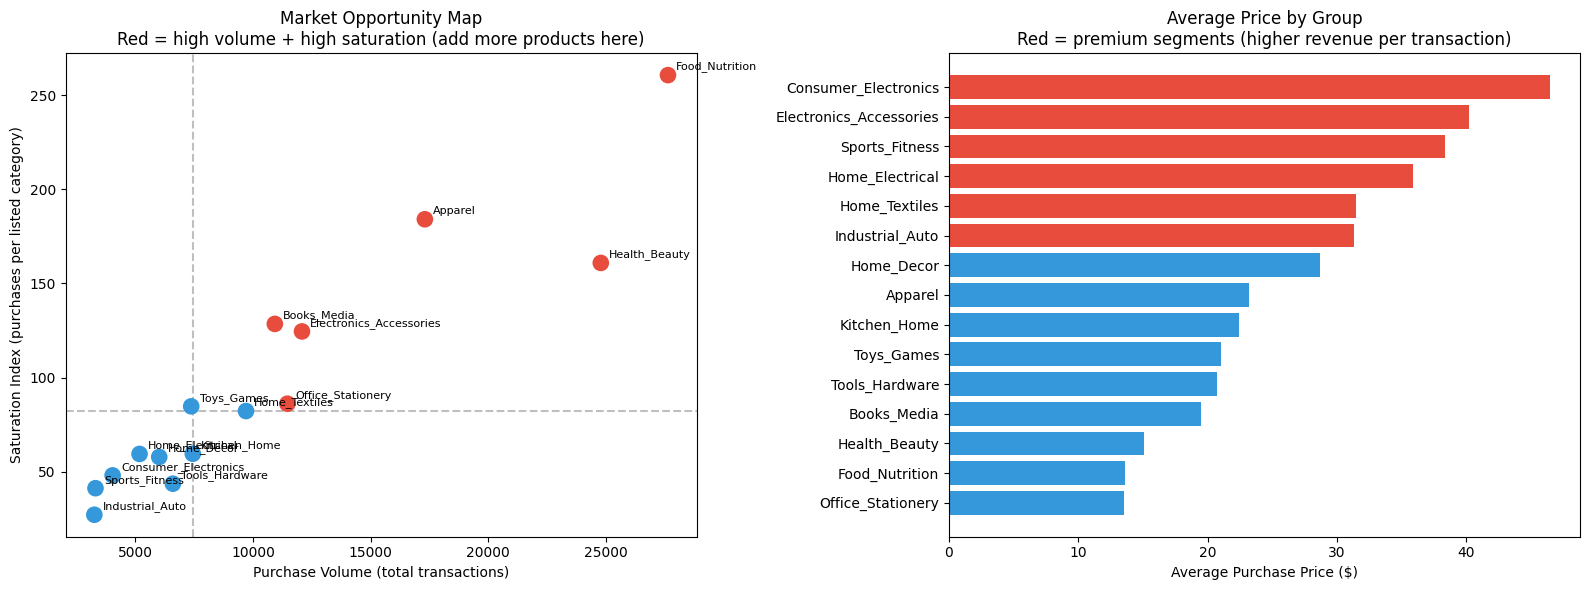

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: volume vs saturation — quadrants tell the opportunity story
ax = axes[0]
colors = ['#e74c3c' if s > market['saturation_index'].median() and v > market['purchase_volume'].median()
          else '#3498db' for s, v in zip(market['saturation_index'], market['purchase_volume'])]
ax.scatter(market['purchase_volume'], market['saturation_index'], s=120, c=colors, zorder=3)
for _, r in market.iterrows():
    ax.annotate(r['parent_label'], (r['purchase_volume'], r['saturation_index']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.axvline(market['purchase_volume'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(market['saturation_index'].median(), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Purchase Volume (total transactions)')
ax.set_ylabel('Saturation Index (purchases per listed category)')
ax.set_title('Market Opportunity Map\nRed = high volume + high saturation (add more products here)')

# Average price by group
market_price = market.sort_values('avg_price')
bars = axes[1].barh(market_price['parent_label'], market_price['avg_price'],
                    color=['#e74c3c' if p > 30 else '#3498db' for p in market_price['avg_price']])
axes[1].set_xlabel('Average Purchase Price ($)')
axes[1].set_title('Average Price by Group\nRed = premium segments (higher revenue per transaction)')

plt.tight_layout()
plt.show()

## 8b. Cross-Category Investment Map

**Business question:** *If a seller currently sells in category A, which category B should they expand into — and how much will their existing customers spend there?*

For each pair (A, B), we find all customers who bought in BOTH categories and compute the **average highest price they paid in category B**. A high cell value means: "customers who buy from you in A are willing to spend a lot in B." Combined with purchase frequency, this identifies the highest-revenue expansion opportunities.

Diagonal cells (A → A) are excluded — this is purely about cross-category moves.

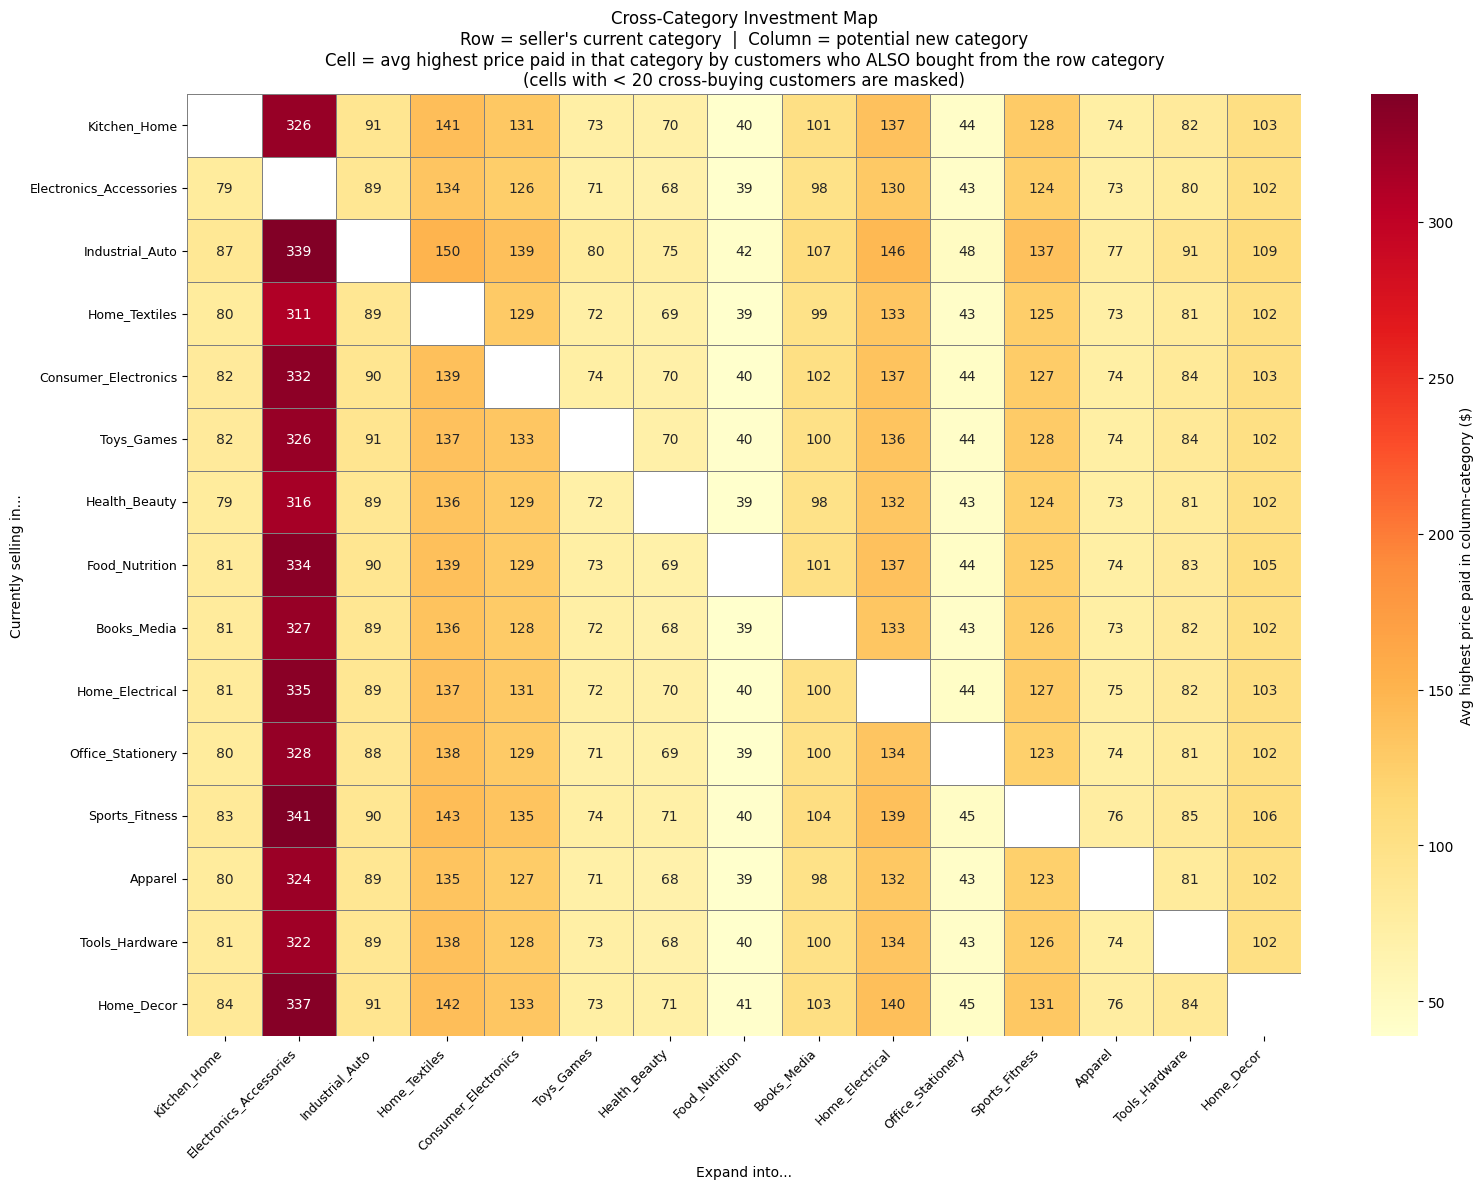

Top 15 expansion opportunities (by avg highest price paid by cross-buyers):
    Current_Category               Expand_To  Avg_Max_Price
      Sports_Fitness Electronics_Accessories     341.114853
     Industrial_Auto Electronics_Accessories     339.176871
          Home_Decor Electronics_Accessories     337.053306
     Home_Electrical Electronics_Accessories     334.647101
      Food_Nutrition Electronics_Accessories     334.239748
Consumer_Electronics Electronics_Accessories     331.973000
   Office_Stationery Electronics_Accessories     327.688248
         Books_Media Electronics_Accessories     326.575902
        Kitchen_Home Electronics_Accessories     326.326641
          Toys_Games Electronics_Accessories     326.088918
             Apparel Electronics_Accessories     324.063714
      Tools_Hardware Electronics_Accessories     322.094803
       Health_Beauty Electronics_Accessories     316.376836
       Home_Textiles Electronics_Accessories     310.706126
     Industrial_Auto    

In [29]:
# unenc already has parent_id + parent_label from cell cf9e2920 — no re-merge needed
sid = pd.read_csv('../data/data_unencoded.csv', usecols=['Survey ResponseID'])
unenc_invest = unenc.dropna(subset=['parent_id']).copy()
unenc_invest['survey_id'] = sid.loc[unenc_invest.index, 'Survey ResponseID'].values
unenc_invest['parent_id'] = unenc_invest['parent_id'].astype(int)

# Per-customer, per-category: max price paid
cust_cat = (
    unenc_invest
    .groupby(['survey_id', 'parent_id'])['Purchase Price Per Unit']
    .max()
    .reset_index()
)
cust_cat.columns = ['survey_id', 'cat', 'max_price']

# Self-join: for every (customer, cat_A) × (customer, cat_B) pair with A ≠ B,
# record max_price in B — how much that customer spent in B
pairs = cust_cat.merge(cust_cat, on='survey_id', suffixes=('_a', '_b'))
pairs = pairs[pairs['cat_a'] != pairs['cat_b']]

# Aggregate: avg(max_price_b) and customer count for each (A, B)
agg = pairs.groupby(['cat_a', 'cat_b']).agg(
    avg_max_price=('max_price_b', 'mean'),
    n_customers  =('max_price_b', 'count')
).reset_index()

# Build 15×15 pivot; mask cells with fewer than 20 customer cross-purchases
price_pivot = agg.pivot(index='cat_a', columns='cat_b', values='avg_max_price')
count_pivot = agg.pivot(index='cat_a', columns='cat_b', values='n_customers')

price_pivot = price_pivot.reindex(index=range(15), columns=range(15))
count_pivot = count_pivot.reindex(index=range(15), columns=range(15))

labels = [id_to_label[i] for i in range(15)]
price_pivot.index   = labels; price_pivot.columns   = labels
count_pivot.index   = labels; count_pivot.columns   = labels

masked_price = price_pivot.where(count_pivot >= 20)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    masked_price, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Avg highest price paid in column-category ($)'}
)
ax.set_title(
    'Cross-Category Investment Map\n'
    'Row = seller\'s current category  |  Column = potential new category\n'
    'Cell = avg highest price paid in that category by customers who ALSO bought from the row category\n'
    '(cells with < 20 cross-buying customers are masked)'
)
ax.set_xlabel('Expand into...')
ax.set_ylabel('Currently selling in...')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Top opportunities ranked by avg price
opp = masked_price.stack().reset_index()
opp.columns = ['Current_Category', 'Expand_To', 'Avg_Max_Price']
opp = opp.sort_values('Avg_Max_Price', ascending=False)
print('Top 15 expansion opportunities (by avg highest price paid by cross-buyers):')
print(opp.head(15).to_string(index=False))

## 9. Product Category Advisor

Given a description of a **new product**, this tool finds the most semantically similar existing Amazon categories and recommends which consolidated group it belongs to. It uses the same sentence-transformer embeddings built in notebook 15.\n\nThis answers: *\"If we want to add a new product, where does it fit, and what already-popular categories are most like it?\"*"

In [30]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize as sk_normalize

# Load pre-computed embeddings — 1,625 × 384, alphabetically sorted by Category
cat_embeddings = np.load('../data/category_embeddings.npy')
cat_lookup = pd.read_csv('../data/category_mapping.csv')  # same alphabetical order

# Also get purchase volume per category for context
cat_volume = unenc.groupby('Category').size().rename('volume')
cat_lookup = cat_lookup.merge(cat_volume, on='Category', how='left')

st_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded. Ready to categorize products.')

def categorize_product(description, top_k=6):
    emb = sk_normalize(st_model.encode([description]))
    sims = (cat_embeddings @ emb.T).flatten()
    top_idx = sims.argsort()[::-1][:top_k]

    rows = cat_lookup.iloc[top_idx].copy()
    rows['similarity'] = sims[top_idx]

    recommended_group = rows['parent_label'].value_counts().idxmax()

    print(f'\n{"=" * 80}')
    print(f'Product: "{description}"')
    print(f'{"=" * 80}')
    print(f'{"Category":<42} {"Group":<26} {"Similarity":>10} {"Volume":>8}')
    print('-' * 88)
    for _, r in rows.iterrows():
        print(f'{r["Category"]:<42} {r["parent_label"]:<26} {r["similarity"]:>10.3f} {int(r["volume"]) if pd.notna(r["volume"]) else 0:>8,}')
    print(f'\n  → Recommended group: {recommended_group}')
    return recommended_group

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11054.31it/s]


Model loaded. Ready to categorize products.


In [31]:
# ── Demo: categorize potential new products ───────────────────────────────────
# Each result shows which existing categories the new product is most similar to,
# what group it belongs to, and how many existing purchases those categories already get.
# High volume in similar categories = proven demand for this type of product.

categorize_product("Wireless noise-cancelling over-ear headphones with 30-hour battery life")
categorize_product("Organic matcha green tea powder, ceremonial grade, 100g resealable bag")
categorize_product("Adjustable dumbbell set 5-52.5 lbs, compact home gym with storage tray")
categorize_product("Anti-aging retinol face serum with hyaluronic acid, vitamin C, SPF 30")
categorize_product("Smart LED desk lamp with wireless charging pad and USB-C port")


Product: "Wireless noise-cancelling over-ear headphones with 30-hour battery life"
Category                                   Group                      Similarity   Volume
----------------------------------------------------------------------------------------
HEADPHONES                                 Consumer_Electronics            0.443    1,065
EARPLUG                                    Consumer_Electronics            0.416       91
HEADPHONE_EARPAD                           Consumer_Electronics            0.405       68
EARMUFF                                    Consumer_Electronics            0.389       48
HEARING_AMPLIFIER                          Consumer_Electronics            0.383        5
PHONE                                      Consumer_Electronics            0.354        2

  → Recommended group: Consumer_Electronics

Product: "Organic matcha green tea powder, ceremonial grade, 100g resealable bag"
Category                                   Group                     

'Electronics_Accessories'